In [2]:
# @title 1. Install & Setup
!pip install neo4j pandas scikit-learn wandb matplotlib seaborn -q

In [3]:

import os
import random
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neo4j import GraphDatabase
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Reproducibility (House Rules)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

wandb.login()

wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# @title 2. Data Extraction
URI = "neo4j+s://ccf24920.databases.neo4j.io"
AUTH = ("neo4j", "YHXssrChTu3r3FinSLYiNVUBhXoUEjcUDM-h0ERxD1E")
driver = GraphDatabase.driver(URI, auth=AUTH)

In [5]:
def get_advanced_data(driver):
    query = """
    MATCH (a:Article)
    OPTIONAL MATCH (a)-[:RELATES_TO_RIGHT]->(r:Right)
    OPTIONAL MATCH (a)-[:GOVERNS]->(i:Institution)
    OPTIONAL MATCH (a)-[:TAGGED]->(t:Tag)
    OPTIONAL MATCH (a)<-[:REFERENCES]-(ref:Article)
    RETURN
        a.id as id,
        a.text as text,
        a.title as title,
        labels(a) as neo4j_labels,
        collect(distinct r.name) as rights,
        collect(distinct i.name) as institutions,
        collect(distinct t.name) as tags,
        count(distinct ref) as citation_count
    """
    with driver.session() as session:
        result = session.run(query)
        df = pd.DataFrame([r.data() for r in result])
    return df


In [6]:
def label_data(df):
    labels = []

    for _, row in df.iterrows():
        text = (
            str(row.get("text", "")) + " " + str(row.get("title", ""))
        ).lower()

        neo_labels = row["neo4j_labels"]
        rights = row["rights"]
        insts = row["institutions"]
        tags = row["tags"]

        # PRIORITY 1: OFFICIAL STRUCTURE
        if "FundamentalRight" in neo_labels or any(rights):
            labels.append(0)  # Rights

        # PRIORITY 2: GRAPH CONNECTIONS
        elif any(i in insts for i in ["Supreme Court", "High Court", "Judiciary"]):
            labels.append(1)  # Judiciary
        elif any(i in insts for i in ["President", "Prime Minister", "Federal Parliament"]):
            labels.append(3)  # Governance
        elif any(t in tags for t in ["Women", "Dalit", "Children", "Minority"]):
            labels.append(0)  # Rights

        # PRIORITY 3: TEXT KEYWORDS
        elif any(k in text for k in ["court", "judge", "judicial", "tribunal"]):
            labels.append(1)
        elif any(k in text for k in ["province", "local level", "federation"]):
            labels.append(2)
        elif any(k in text for k in ["president", "minister", "parliament", "election"]):
            labels.append(3)
        else:
            labels.append(4)  # Other

    df["label"] = labels
    return df


In [7]:
df = get_advanced_data(driver)
df = label_data(df)

print("Class Distribution:")
print(df["label"].value_counts())


Class Distribution:
label
4    98
0    80
3    78
1    38
2    14
Name: count, dtype: int64


In [8]:
run = wandb.init( project="Week-5", name="Day- 3", config={"model": "RandomForest", "seed": SEED, "max_features": 2000} )

In [9]:
# IMPORTANT: same text field used for training
df["full_text"] = (
df["text"].fillna("") + " " + df["title"].fillna("")
)

vectorizer = TfidfVectorizer(
max_features=2000,
stop_words="english",
ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["full_text"]).toarray()
y = df["label"].values


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    class_weight="balanced",
    n_jobs=1  # IMPORTANT: reduces randomness
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [12]:
class_names = ["Rights", "Judiciary", "Federalism", "Governance", "Other"]

print("\nCLASSIFICATION REPORT:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


CLASSIFICATION REPORT:

              precision    recall  f1-score   support

      Rights       0.80      0.60      0.69        20
   Judiciary       1.00      0.89      0.94         9
  Federalism       1.00      1.00      1.00         3
  Governance       0.84      0.80      0.82        20
       Other       0.69      0.88      0.77        25

    accuracy                           0.79        77
   macro avg       0.87      0.83      0.84        77
weighted avg       0.81      0.79      0.79        77



In [13]:
# --- 1. CLASSIFICATION REPORT ---
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
wandb.log({"classification_report": wandb.Table(dataframe=pd.DataFrame(report_dict).T)})

In [15]:
from sklearn.metrics import f1_score

In [16]:
report = classification_report(
  y_test,
  y_pred,
  target_names=class_names,
  zero_division=0
)
print("Classification Report")
print(report)

# Convert to dict for W&B
report_dict = classification_report(
  y_test,
  y_pred,
  target_names=class_names,
  output_dict=True,
  zero_division=0
)

wandb.log({
  "classification_report": wandb.Table(
      dataframe=pd.DataFrame(report_dict).T
  )
})

# ---- Macro F1 ----
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"\nMacro F1 Score: {macro_f1:.4f}")

wandb.log({"macro_f1": macro_f1})

Classification Report
              precision    recall  f1-score   support

      Rights       0.80      0.60      0.69        20
   Judiciary       1.00      0.89      0.94         9
  Federalism       1.00      1.00      1.00         3
  Governance       0.84      0.80      0.82        20
       Other       0.69      0.88      0.77        25

    accuracy                           0.79        77
   macro avg       0.87      0.83      0.84        77
weighted avg       0.81      0.79      0.79        77


Macro F1 Score: 0.8439


Text(0.5, 58.7222222222222, 'Predicted Label')

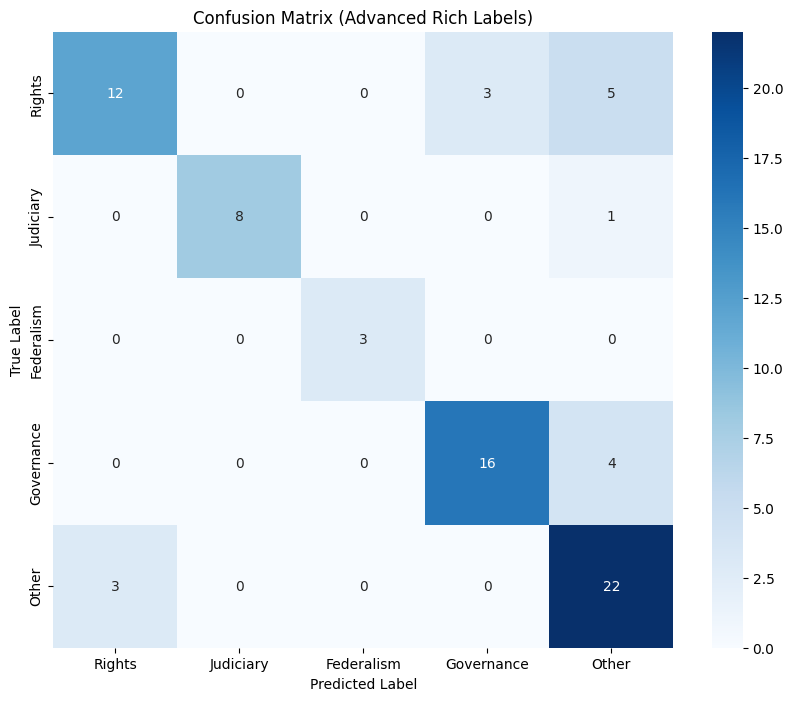

In [17]:
# --- 2. CONFUSION MATRIX ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Advanced Rich Labels)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

In [18]:
# ROBUST SAVING
filename_cm = "confusion_matrix_final.png"
plt.savefig(filename_cm, bbox_inches='tight', dpi=150)
wandb.log({"confusion_matrix": wandb.Image(filename_cm)})
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

In [23]:
# Predict probabilities (needed for ROC)
y_score = model.predict_proba(X_test)

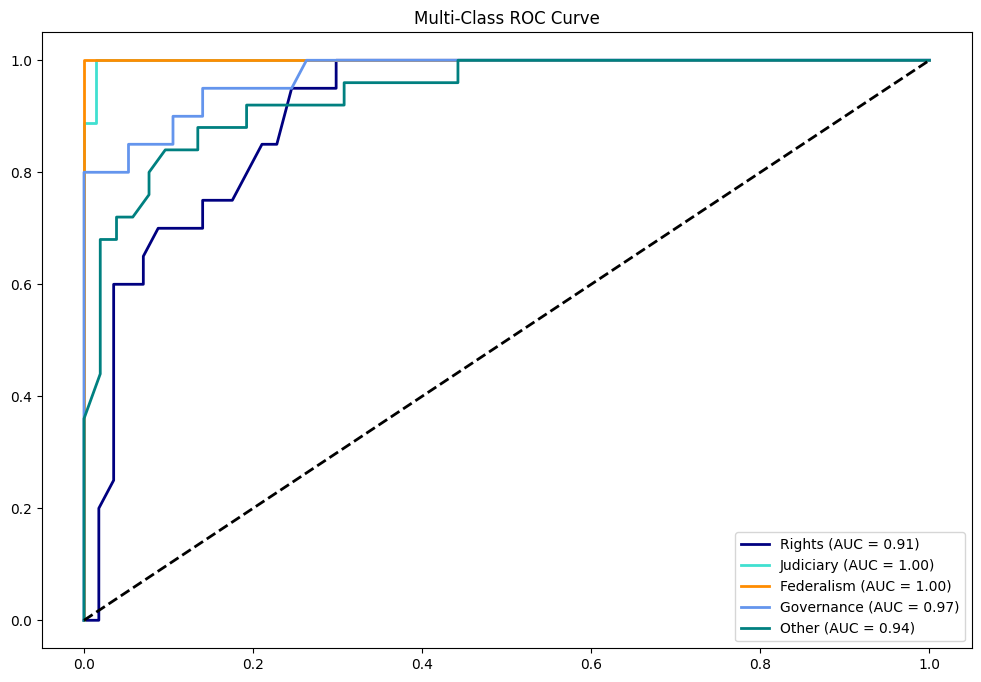

In [25]:
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Binarize the test labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
n_classes = y_test_bin.shape[1]

# Compute FPR, TPR, AUC for each class
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(12, 8))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [26]:
# ROBUST SAVING
filename_roc = "roc_curve_final.png"
plt.savefig(filename_roc, bbox_inches='tight', dpi=150)
wandb.log({"roc_curve": wandb.Image(filename_roc)})
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

In [27]:
run.finish()

macro_f1,▁
macro_f1,0.84387
